In [101]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [267]:
dt = pd.read_csv("dataset.csv")
dt

,Unnamed: 0,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
0,1,NaN,1.0,NaN,NaN,2.0,3.0,NaN,3.0,1,NaN
1,2,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
2,3,NaN,2.0,NaN,NaN,1.0,NaN,NaN,2.0,1,NaN
3,4,NaN,1.0,25.608588,NaN,NaN,2.0,NaN,NaN,NaN,1.0
4,5,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...
297,2651,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,308,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,347,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,378,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0


In [268]:
dt = dt.drop("Unnamed: 0", axis="columns", inplace=False)

In [283]:
dt.dtypes

Age                  float64
Menopause            float64
Taille_tumeur        float64
Ganglions_touches    float64
Metastases           float64
Grade                float64
Lateralite           float64
Quadrant             float64
Irradiation           object
Recidive             float64
dtype: object

In [140]:
dt.isnull().sum()

Age                  110
Menopause             40
Taille_tumeur        106
Ganglions_touches     81
Metastases            76
Grade                 78
Lateralite            57
Quadrant              87
Irradiation           65
Recidive             136
dtype: int64

<h4>To see if there's no relevant Age data</h4>

Text(0.5, 1.0, "Densité des observations concernant l'âge du patient")

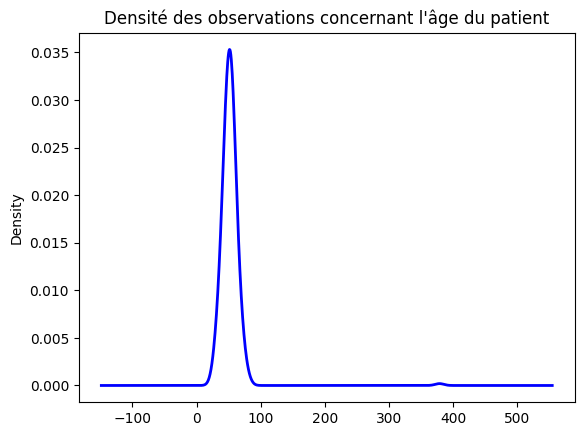

In [119]:
dt["Age"].plot.density(bw_method='scott', color='blue', linestyle='-', linewidth=2)
plt.title("Densité des observations concernant l'âge du patient")

In [8]:
dt["Age"].describe()

count    192.000000
mean      53.059182
std       26.269277
min       27.269382
25%       43.416635
50%       52.367426
75%       58.709683
max      378.787350
Name: Age, dtype: float64

<h4>To see if there's more than 2 values for the menopause and 3 for the grade</h4>

In [9]:
dt["Menopause"].value_counts()

Menopause
1.0    135
2.0    127
Name: count, dtype: int64

In [10]:
#We good fot the menopause variable

In [11]:
dt.Grade.value_counts()

Grade
2.0     97
3.0     72
1.0     54
34.0     1
Name: count, dtype: int64

In [12]:
#We only have 1 record with the observation 34. We can suppose that the doctor type 34 by mistake. The one wanted was probably 3

<h5>No the correlation between the age and the menopause</h5>

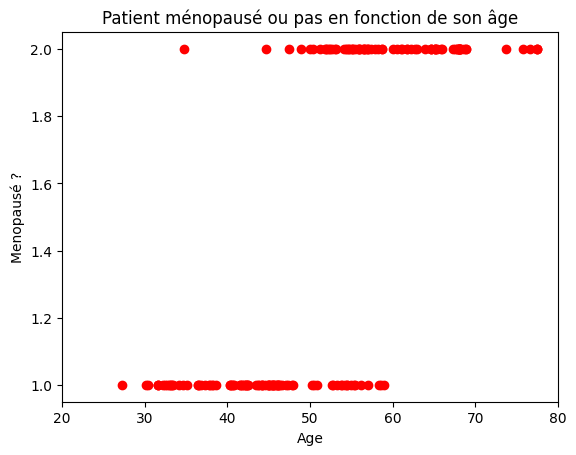

In [173]:
plt.scatter(dt["Age"], dt["Menopause"], color="red")
plt.title("Patient ménopausé ou pas en fonction de son âge")
plt.xlabel("Age")
plt.ylabel("Menopausé ?")
plt.xlim(20, 80)
plt.show()

In [14]:
#The values of age are very close so the scatter plot doesn't give much information. We can't see clearly if there's a pattern

<h4>Tumor size density</h4>

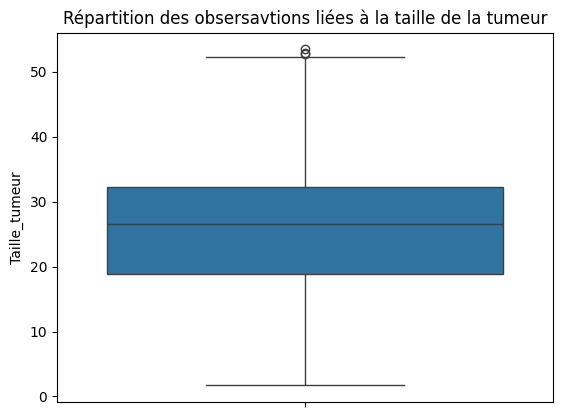

In [81]:
sns.boxplot(data = dt["Taille_tumeur"])
#plt.ylim(50, 55)
plt.title("Répartition des obsersavtions liées à la taille de la tumeur")
plt.show()

In [16]:
dt["Taille_tumeur"].describe()

count    196.000000
mean      26.127106
std       10.389460
min        1.714647
25%       18.812693
50%       26.549199
75%       32.257666
max       53.422745
Name: Taille_tumeur, dtype: float64

In [17]:
#Un graphique Q-Q (Quantile-Quantile) est utilisé pour vérifier si un ensemble de données suit une distribution théorique particulière.
#QQPlot on tumor size + Shapiro test to see if it rejects null hypotesis ( pvalue > 0.5 )

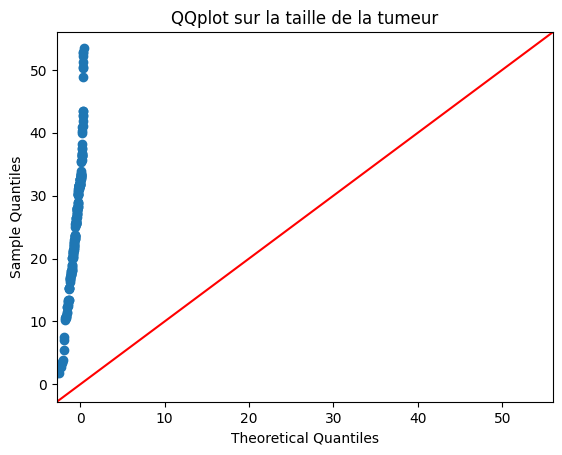

In [48]:
import statsmodels.api as sm
import pylab as py

sm.qqplot(dt["Taille_tumeur"], line = '45')
py.title("QQplot sur la taille de la tumeur")
py.show()

In [23]:
from scipy.stats import shapiro

rounded = dt
shapiroo = shapiro(rounded["Taille_tumeur"])
shapiroo

ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [24]:
#It doesn't work with Null Values
rounded = rounded.dropna(subset=["Taille_tumeur"])
rounded

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
1,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
3,NaN,1.0,25.608588,NaN,NaN,2.0,NaN,NaN,NaN,1.0
4,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
5,46.298965,1.0,10.601184,2.0,1.0,2.0,1.0,3.0,1,1.0
9,56.972747,2.0,30.606762,0.0,NaN,NaN,2.0,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...
297,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0


In [25]:
shapiroo = shapiro(rounded["Taille_tumeur"])
shapiroo

ShapiroResult(statistic=np.float64(0.9834111157624116), pvalue=np.float64(0.0205546977172848))

In [26]:
#P_value < 0.05 so we reject null hypothesis. Like the QQPlot shows us, the tumor size is not following the normal law

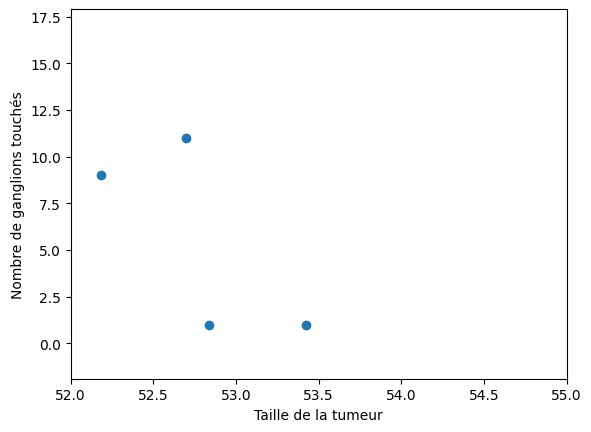

In [80]:
plt.scatter(dt["Taille_tumeur"], dt["Ganglions_touches"])
plt.xlim(52,55)
plt.xlabel("Taille de la tumeur")
plt.ylabel("Nombre de ganglions touchés")
plt.show()

<h3>Test de Grubs pour savoir mathématiquement s'il y a des valeurs aberrantes pour la taille de la tumeur</h3>

<h3>Ganglions touchés</h3>

In [29]:
import seaborn as sns

<Axes: ylabel='Ganglions_touches'>

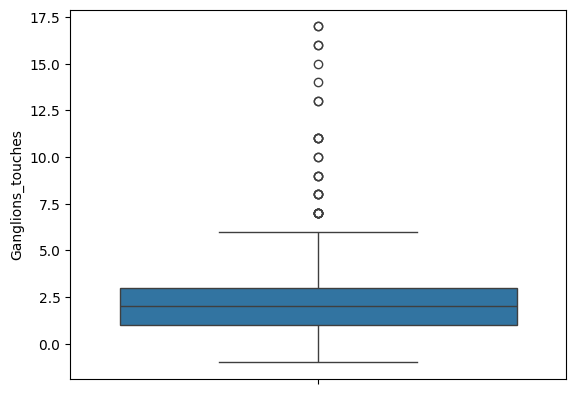

In [30]:
sns.boxplot(data = dt["Ganglions_touches"])

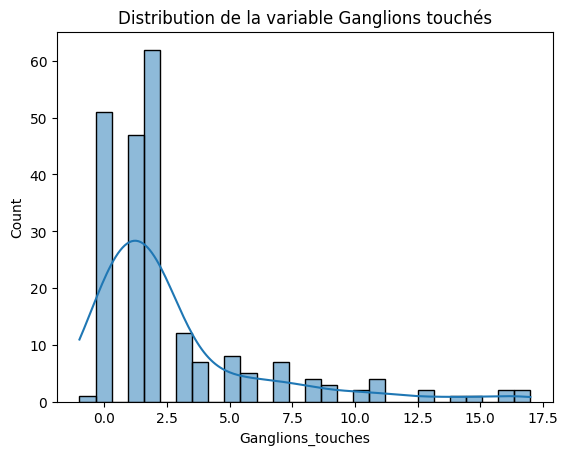

In [31]:
sns.histplot(dt["Ganglions_touches"], kde=True)
plt.title("Distribution de la variable Ganglions touchés")
plt.show()

In [32]:
dt[dt["Ganglions_touches"] < 0].head()
#Nous pouvons voir qu'un patient possède une valeur négative

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
76,65.114903,2.0,31.212433,-1.0,1.0,2.0,1.0,2.0,2,1.0


In [33]:
#Comme nous avons des valeurs <= 0, nous ne pouvons pas faire BoxCox ( log(x) et log(0) existe pas )
#Nous faisons donc Yeo-Johnson

In [34]:
#De plus, avoir plus de 10 ganglions touché pour un patient est rare.
#Mais pas imposible.Pour savoir si notre observation est aberrantes, nous allons la comparer avec la taille de la tumeur. 
#Si beaucoup de ganglions touchés mais une taille de tumeur petite, nous pouvons conclure que c'est une erreur.

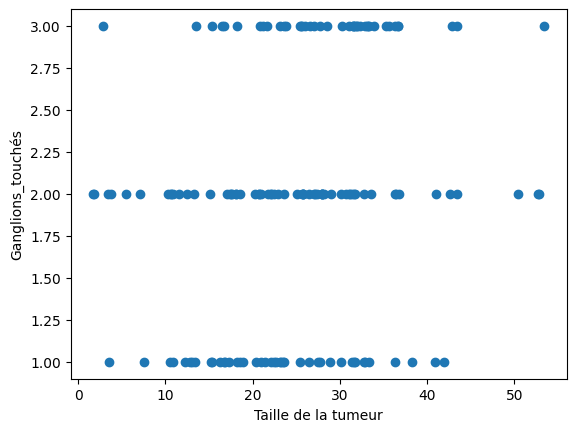

In [223]:
big_ganglions = dt[dt["Ganglions_touches"] > 9]
plt.scatter(dt["Taille_tumeur"], dt["Grade"])
plt.ylabel("Ganglions_touchés")
plt.xlabel("Taille de la tumeur")
plt.show()

In [36]:
#Aucun lien, aucun cluster, les variables sont indépendantes

<h4>Metastases</h4>

In [37]:
dt["Metastases"].value_counts() 
# 1 = Metastase visible
# 2 = Metastase non visible
# Autre = Valeur aberrante

Metastases
1.0    178
2.0     48
Name: count, dtype: int64

<h4>Grade</h4>

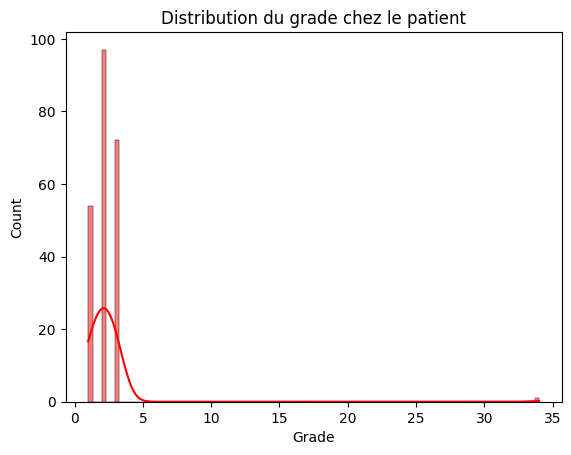

In [38]:
sns.histplot(dt["Grade"], kde=True, color="red")
plt.title("Distribution du grade chez le patient")
plt.show()

In [39]:
#We can see a dot near the 35.
#So we look in detail
dt['Grade'].value_counts()

Grade
2.0     97
3.0     72
1.0     54
34.0     1
Name: count, dtype: int64

<h4>Lateralité</h4>

In [40]:
#Valeur possible : 1 & 2
# 1 -> cancer sein gauche
# 2 -> cancr sein droit
#Autre -> Ano

dt["Lateralite"].value_counts()

Lateralite
1.0    131
2.0    114
Name: count, dtype: int64

<h4>Quadrant</h4>

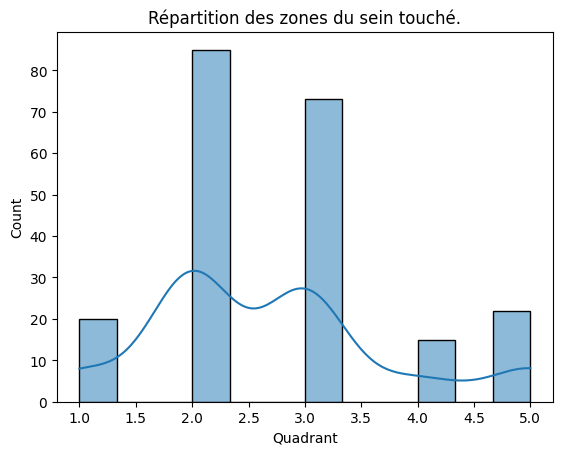

In [41]:
sns.histplot(dt["Quadrant"], kde=True)
plt.title("Répartition des zones du sein touché.")
plt.show()

<h4>Irradiation</h4>

In [290]:
dt["Irradiation"] = pd.to_numeric(dt["Irradiation"], errors='coerce')

In [291]:
#We think if tumor size < 5 cm & ganglions touché = 0 --> no irradiation ( cause small )
#First of all let's check if irraidtion != 1 or != 2

dt.Irradiation.value_counts()

Irradiation
1.0    177
2.0     59
Name: count, dtype: int64

In [296]:
no_irradiation = dt[dt['Irradiation'] == 1]
irradiation = dt[dt["Irradiation"] == 2]

In [297]:
no_irradiation.describe()

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
count,177.000000,177.000000,121.000000,133.000000,143.000000,146.000000,177.000000,177.000000,177.0,111.000000
mean,51.294280,1.480226,25.084786,1.894737,1.111888,1.952055,1.446328,2.553672,1.0,1.342342
std,9.951493,0.501026,11.654943,2.635030,0.316337,0.745859,0.498521,1.027298,0.0,0.476645
min,27.269382,1.000000,1.714647,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
25%,44.964164,1.000000,17.510634,0.000000,1.000000,1.000000,1.000000,2.000000,1.0,1.000000
50%,51.922122,1.000000,23.642077,2.000000,1.000000,2.000000,1.000000,2.000000,1.0,1.000000
75%,56.985184,2.000000,31.777624,2.000000,1.000000,2.750000,2.000000,3.000000,1.0,2.000000
max,77.520720,2.000000,53.422745,17.000000,2.000000,3.000000,2.000000,5.000000,1.0,2.000000


In [298]:
irradiation.describe()

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
count,59.000000,59.000000,26.000000,37.000000,32.000000,46.000000,59.000000,59.000000,59.0,23.000000
mean,50.491939,1.525424,28.039203,4.810811,1.468750,2.347826,1.474576,2.932203,2.0,1.434783
std,9.911736,0.503640,7.389997,4.313015,0.507007,0.706081,0.503640,1.064545,0.0,0.506870
min,30.365161,1.000000,13.470898,-1.000000,1.000000,1.000000,1.000000,1.000000,2.0,1.000000
25%,45.084877,1.000000,25.495463,1.000000,1.000000,2.000000,1.000000,2.000000,2.0,1.000000
50%,49.970130,2.000000,28.701148,4.000000,1.000000,2.000000,1.000000,3.000000,2.0,1.000000
75%,55.398493,2.000000,33.012161,7.000000,2.000000,3.000000,2.000000,4.000000,2.0,2.000000
max,77.500805,2.000000,42.607066,17.000000,2.000000,3.000000,2.000000,5.000000,2.0,2.000000


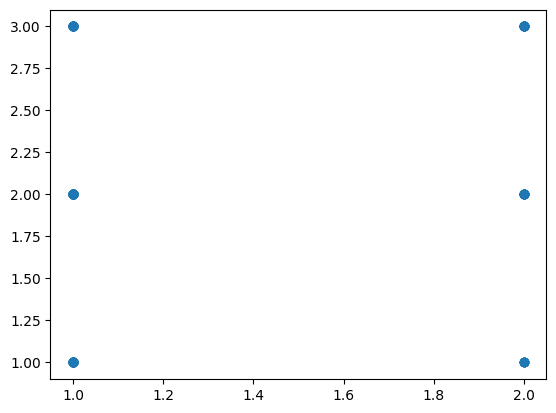

In [295]:
plt.scatter(dt.Irradiation, dt["Grade"])
plt.show()

<h4>Recidive</h4>

In [44]:
dt.Recidive.value_counts()

Recidive
1.0    101
2.0     65
Name: count, dtype: int64

In [45]:
#Recap valeurs aberantes:
#Age -> 1 observation ; 378
#Grade -> 1 observation : 34
#Ganglion_touche -> 1 observation : -1

<h4>Traitement données aberrantes</h4>

<h5>Age</h5>

In [269]:
dt.loc[dt["Age"] > 350, "Age"] = dt["Age"] / 10# On suppose que le patient à 37,78735 car non ménopausé.

<h5>Nombre de ganglions</h5>

In [70]:
grade1 = dt[dt["Grade"] == 1]
grade2 = dt[dt["Grade"] == 2]
grade3 = dt[dt["Grade"] == 3]

In [75]:
dt[dt["Ganglions_touches"] == -1]

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
76,65.114903,2.0,31.212433,-1.0,1.0,2.0,1.0,2.0,2.0,1.0


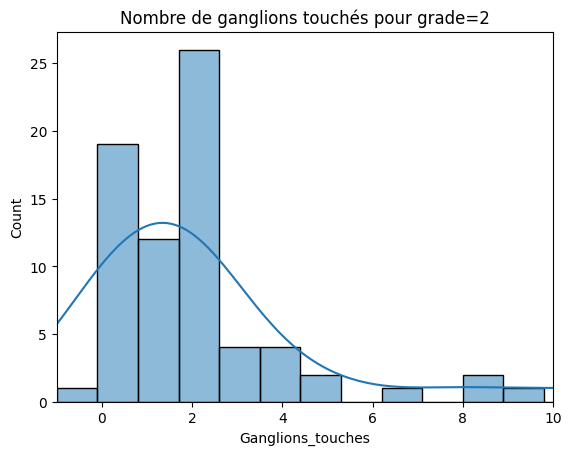

In [78]:
sns.histplot(grade2["Ganglions_touches"], kde=True)
plt.title("Nombre de ganglions touchés pour grade=2")
plt.xlim(-1, 10)
plt.show()

In [ ]:
#We choose to change -1 to 1 cause majority of distribution.

<h5>Grade</h5>

In [82]:
dt[dt["Grade"] == 34]

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
232,57.542278,NaN,NaN,4.0,2.0,34.0,2.0,NaN,NaN,NaN


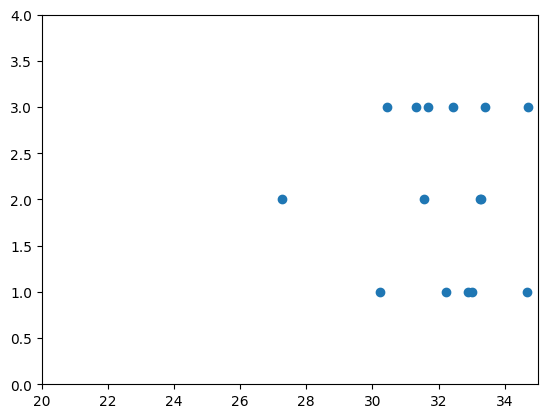

In [89]:
recidive = dt[dt["Age"]<35]

plt.scatter(recidive["Age"], recidive["Grade"])
plt.xlim(20, 35)
plt.ylim(0,4)
plt.show()


In [90]:
recidive

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
28,32.230700,1.0,18.913529,2.0,1.0,1.0,1.0,2.0,1.0,1.0
34,34.665583,1.0,17.339789,1.0,1.0,1.0,1.0,2.0,1.0,1.0
49,31.573261,1.0,25.798925,2.0,1.0,2.0,2.0,2.0,1.0,1.0
51,30.223943,1.0,12.217858,2.0,1.0,1.0,2.0,2.0,1.0,1.0
60,33.243909,1.0,1.801674,0.0,1.0,2.0,2.0,1.0,1.0,1.0
89,27.269382,1.0,36.445383,0.0,1.0,2.0,2.0,5.0,1.0,1.0
102,32.424542,1.0,28.543095,5.0,2.0,3.0,1.0,2.0,2.0,2.0
165,34.715689,2.0,16.689622,2.0,1.0,3.0,2.0,3.0,1.0,1.0
189,31.609554,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN
213,32.895294,1.0,18.499644,2.0,1.0,1.0,2.0,2.0,1.0,2.0


<h3> Données manquantes</h3>

In [91]:
#Nous avons une distribution sans structure car aucune varibale de temporalité et les non-observations sont aléatoire.
#Rien ne nous permet de définir une structure et un schéma pour les valeurs manquantes.

In [92]:
#On va essayer de voir si MAR ( si une variable nulle va avoir une incidence sur une autre variable.

In [93]:
#Nous pensons que si taille_tumeur == null -> nbe ganglions_touches == null

In [98]:
mar_taille_tumeur = dt[dt["Taille_tumeur"].isnull()]
print(f"Nb de valeurs null pour la taille de la tumeur : {mar_taille_tumeur.Taille_tumeur.isnull().sum()}")
print(f"Nb de valeurs null pour le nombre de ganglions : {mar_taille_tumeur.Ganglions_touches.isnull().sum()}")

Nb de valeurs null pour la taille de la tumeur : 106
Nb de valeurs null pour le nombre de ganglions : 66


In [99]:
mar_taille_tumeur

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
0,NaN,1.0,NaN,NaN,2.0,3.0,NaN,3.0,1.0,NaN
2,NaN,2.0,NaN,NaN,1.0,NaN,NaN,2.0,1.0,NaN
6,45.554682,NaN,NaN,0.0,1.0,2.0,2.0,NaN,NaN,NaN
7,NaN,NaN,NaN,17.0,NaN,2.0,2.0,3.0,2.0,NaN
8,65.124040,2.0,NaN,NaN,1.0,NaN,2.0,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...
281,NaN,2.0,NaN,NaN,1.0,3.0,NaN,2.0,1.0,NaN
284,NaN,NaN,NaN,11.0,NaN,2.0,2.0,3.0,1.0,NaN
285,NaN,1.0,NaN,NaN,1.0,3.0,NaN,5.0,1.0,NaN
286,58.131884,NaN,NaN,2.0,1.0,2.0,1.0,NaN,NaN,NaN


In [ ]:
# So our case is MCAR

<h3>Fill N/A</h3>

In [270]:
#We fill the N/As with random values between the first quartile and the 3rd quartile
dt["Age"] = dt["Age"].apply(lambda l: l if not np.isnan(l).all() else np.random.uniform(43.416635, 58.71))
dt

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
0,58.407463,1.0,NaN,NaN,2.0,3.0,NaN,3.0,1,NaN
1,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
2,51.086862,2.0,NaN,NaN,1.0,NaN,NaN,2.0,1,NaN
3,48.655614,1.0,25.608588,NaN,NaN,2.0,NaN,NaN,NaN,1.0
4,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...
297,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0


In [273]:
no_menopause = dt[dt["Menopause"] == 1]
max_age = no_menopause["Age"].max()
menopause = dt[dt["Menopause"] == 2 ]
min_age = 45 # On ne fait pas min() car il y a une femme ménopausé avec un age ~ 33 ans

na_values = dt["Menopause"].isnull()
remaining = na_values & (dt["Age"] <= max_age) & (dt.Age >= min_age)

dt.loc[na_values & ( dt.Age > max_age), "Menopause"] = 2
dt.loc[na_values & ( dt.Age < min_age), "Menopause"] = 1
dt.loc[remaining, "Menopause"] = np.random.choice([1, 2], size=remaining.sum())


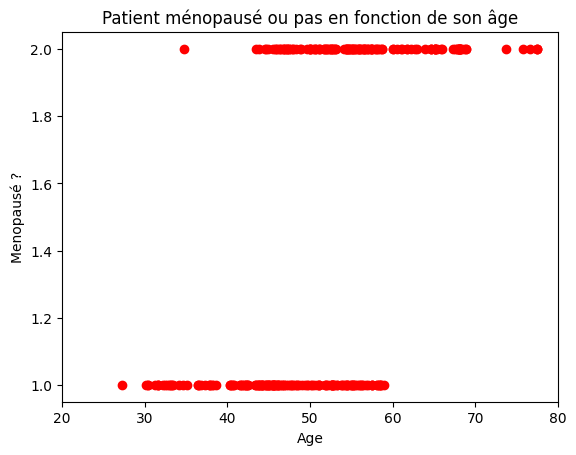

In [275]:
plt.scatter(dt["Age"], dt["Menopause"], color="red")
plt.title("Patient ménopausé ou pas en fonction de son âge")
plt.xlabel("Age")
plt.ylabel("Menopausé ?")
plt.xlim(20, 80)
plt.show()

<h4>Si corrélation entre récidive et (lateralité/quadrant)</h4>

In [276]:
recidive = dt[dt["Recidive"] == 2]
non_recidive = dt[dt["Recidive"] == 1]

<Axes: xlabel='Lateralite', ylabel='Count'>

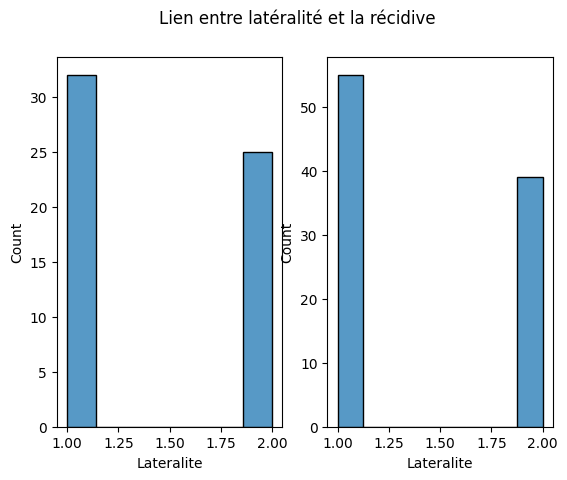

In [277]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Lien entre latéralité et la récidive')
sns.histplot(ax = ax1, x= recidive["Lateralite"])
sns.histplot(ax = ax2, x= non_recidive["Lateralite"])

<Axes: xlabel='Quadrant', ylabel='Count'>

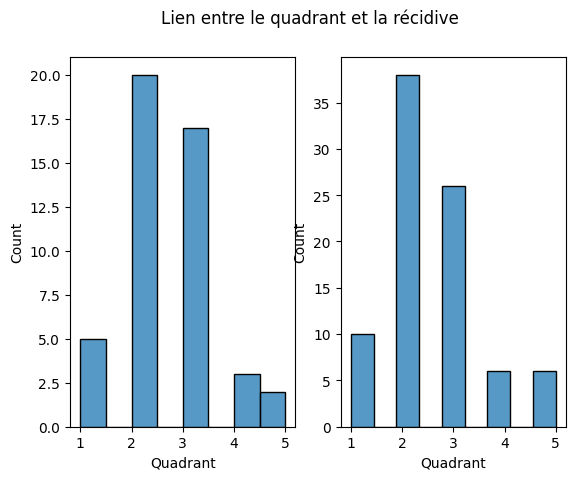

In [278]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Lien entre le quadrant et la récidive')
sns.histplot(ax = ax1, x= recidive["Quadrant"])
sns.histplot(ax = ax2, x= non_recidive["Quadrant"])

<Axes: xlabel='Quadrant', ylabel='Count'>

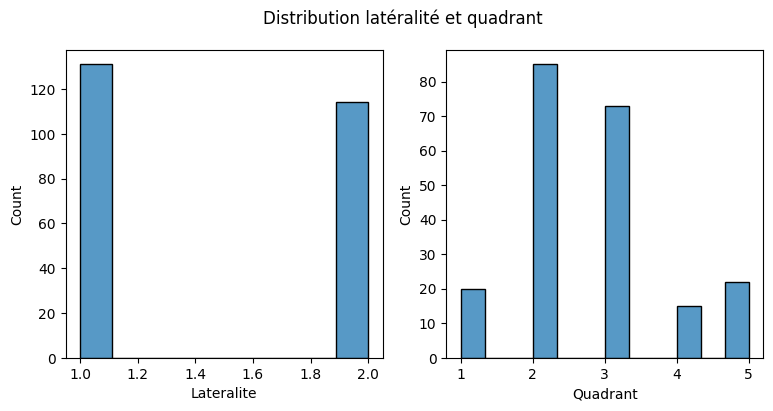

In [279]:
#Aucun incidence mais distribution inégale de part et d'autres.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,4))
fig.suptitle('Distribution latéralité et quadrant')
sns.histplot(ax = ax1, x= dt["Lateralite"])
sns.histplot(ax = ax2, x= dt["Quadrant"])

In [281]:
lat_p1 = dt[dt["Lateralite"] == 1].Lateralite.count() / dt.Lateralite.count()
lat_p2 = dt[dt["Lateralite"] == 2].Lateralite.count() / dt.Lateralite.count()

dt.loc[dt['Lateralite'].isnull(), "Lateralite"] = np.random.choice([1,2], p=[lat_p1, lat_p2], size=dt.Lateralite.isnull().sum())

In [286]:
qua_p1 = dt[dt["Quadrant"] == 1].Quadrant.count() / dt.Quadrant.count()
qua_p2 = dt[dt["Quadrant"] == 2].Quadrant.count() / dt.Quadrant.count()
qua_p3 = dt[dt["Quadrant"] == 3].Quadrant.count() / dt.Quadrant.count()
qua_p4 = dt[dt["Quadrant"] == 4].Quadrant.count() / dt.Quadrant.count()
qua_p5 = dt[dt["Quadrant"] == 5].Quadrant.count() / dt.Quadrant.count()

dt.loc[dt['Quadrant'].isnull(), "Quadrant"] = np.random.choice([1,2,3,4,5], p=[qua_p1, qua_p2, qua_p3, qua_p4, qua_p5], size=dt.Quadrant.isnull().sum())

<Axes: xlabel='Quadrant', ylabel='Count'>

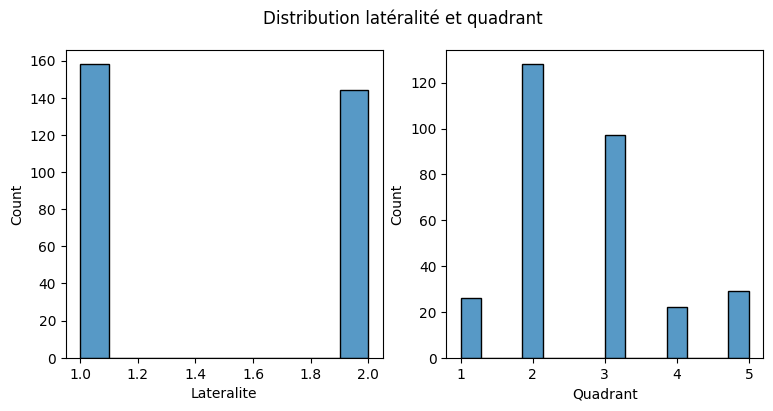

In [287]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,4))
fig.suptitle('Distribution latéralité et quadrant')
sns.histplot(ax = ax1, x= dt["Lateralite"])
sns.histplot(ax = ax2, x= dt["Quadrant"])

In [288]:
dt

,Age,Menopause,Taille_tumeur,Ganglions_touches,Metastases,Grade,Lateralite,Quadrant,Irradiation,Recidive
0,58.407463,1.0,NaN,NaN,2.0,3.0,1.0,3.0,1,NaN
1,51.240996,2.0,16.874618,1.0,1.0,1.0,2.0,1.0,1,1.0
2,51.086862,2.0,NaN,NaN,1.0,NaN,1.0,2.0,1,NaN
3,48.655614,1.0,25.608588,NaN,NaN,2.0,1.0,3.0,NaN,1.0
4,55.254881,2.0,43.438748,2.0,1.0,3.0,1.0,3.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...
297,52.048990,2.0,33.089490,11.0,NaN,3.0,1.0,2.0,2,1.0
298,75.745550,2.0,15.239369,9.0,NaN,1.0,1.0,2.0,2,2.0
299,54.688155,2.0,23.642077,2.0,NaN,1.0,1.0,2.0,1,2.0
300,57.920124,2.0,22.087332,2.0,NaN,1.0,1.0,3.0,1,2.0
